# An empirical analysis of circuit obfuscation with QUIMB

In this notebook, we will perform a few experiments on the obfuscated circuit we previously created in `pyzx_circuit_obfuscation.ipynb`. Please run the latter fully before proceeding : in particular, the files `out/obfuscated_circuit.qasm` and `out/original_circuit.qasm` should exist.

Our study will make use of the [QUIMB](https://quimb.readthedocs.io/en/latest/) library for quantum information using tensor networks.

In [46]:
import quimb.tensor as qtn
import cotengra as ctg

We start by loading the original and obfuscated circuits.

Original and then obfuscated circuits:


(<Figure size 1683.33x166.667 with 1 Axes>, <Axes: >)

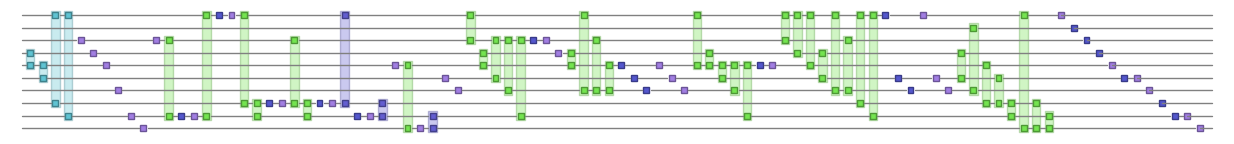

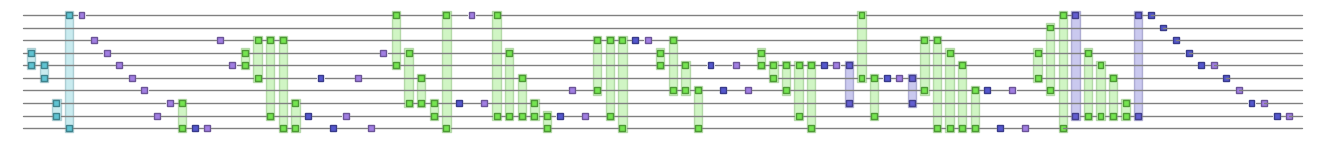

In [47]:
c_original = qtn.Circuit.from_openqasm2_file("../out/original_circuit.qasm")
c_obfuscated = qtn.Circuit.from_openqasm2_file("../out/obfuscated_circuit.qasm")

print("Original and then obfuscated circuits:")
c_original.draw()
c_obfuscated.draw()

Then, convert the circuits to tensor networks :

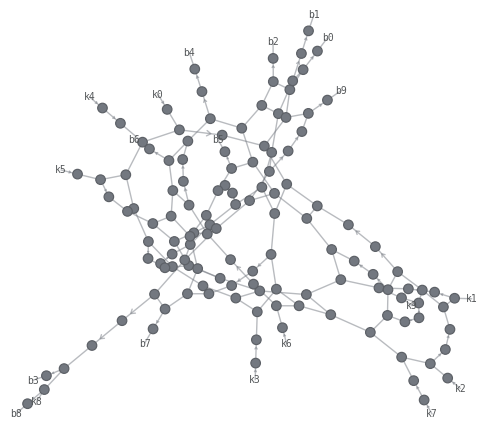

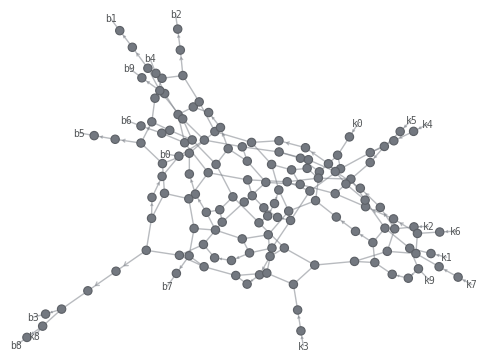

In [48]:
tn_original = c_original.uni
tn_original.draw()

tn_obfuscated = c_obfuscated.uni
tn_obfuscated.draw()

In [49]:
opt = ctg.HyperOptimizer(
    methods=["greedy", "kahypar"], # Algorithmes de recherche
    max_repeats=32,                # Nombre d'essais pour trouver le meilleur chemin
    progbar=True
)

tree = tn_original.contraction_tree(opt)

cost_original = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_original)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=7.05 C=8.16 S=20.00 P=20.32:  16%|█▌        | 5/32 [00:02<00:08,  3.24it/s]/home/hage/anaconda3/lib/python3.13/site-packages/cotengra/hyperoptimizers/hyper.py:403: UserWarning: Trial error: No module named 'kahypar'. Set `HyperOptimizer` kwarg `on_trial_error='raise'` to raise this error, or `on_trial_error='ignore'` to silence.
  warnings.warn(
/home/hage/anaconda3/lib/python3.13/site-packages/cotengra/hyperoptimizers/hyper.py:403: UserWarning: Trial error: No module named 'kahypar'. Set `HyperOptimizer` kwarg `on_trial_error='raise'` to raise this error, or `on_trial_error='ignore'` to silence.
  warnings.warn(
F=7.05 C=8.16 S=20.00 P=20.32: 100%|██████████| 32/32 [00:05<00:00,  6.19it/s]

FLOPs cost (log10) : 7.04942333338056
Max memory (log2)   : 20.0
Operations : 144417968


In [50]:
tree = tn_obfuscated.contraction_tree(opt)

cost_obfuscated = tree.total_flops(log=10)

print("FLOPs cost (log10) :", cost_obfuscated)
print("Max memory (log2)   :", tree.max_size(log=2))
print("Operations :", tree.total_cost())

F=7.05 C=8.16 S=20.00 P=20.32: 100%|██████████| 32/32 [00:07<00:00,  4.35it/s]

FLOPs cost (log10) : 7.04942333338056
Max memory (log2)   : 20.0
Operations : 144417968


In [51]:
# Compute the ratio of the costs
exp = cost_obfuscated - cost_original
print(f"The cost of contracting the obfuscated circuit is {10**exp:.2f} times the cost of contracting the original circuit.")

The cost of contracting the obfuscated circuit is 1.00 times the cost of contracting the original circuit.


Exception ignored in: <function ResourceTracker.__del__ at 0x7ccd20b8d760>
Traceback (most recent call last):
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fb900395760>
Traceback (most recent call last):
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/hage/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7

Repeating the experience with multiple circuits, we see that there doesn't seem to be a notable difference in contracting one circuit or another. This is likely because of the calls to PyZX's `full_reduce` methods on both circuits.